# Interactive Customer Segmentation


This project discovers customer segments from transaction data using K-Means clustering, then builds a classifier so a new customer profile can be assigned to one of the discovered segments.

The final result will be used by a Streamlit application.


## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# Compatibility with older and newer scikit-learn versions
try:
    OneHotEncoder(sparse_output=False)
    OHE_KWARGS = {"handle_unknown": "ignore", "sparse_output": False}
except TypeError:
    OHE_KWARGS = {"handle_unknown": "ignore", "sparse": False}

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load Dataset

The dataset is the transaction dataset used as the starting point for the project.

If the online dataset cannot be accessed, replace `DATA_URL` with the path to your local CSV file.


In [6]:
DATA_URL = "https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv"

df = pd.read_csv(DATA_URL)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (2537, 16)


,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


## 3. Inspect the Data

In [7]:
print("Missing values:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
display(df.dtypes)


Missing values:


Location                   30
DeviceID                   30
TransactionType            30
TransactionID              29
PreviousTransactionDate    28
Channel                    27
AccountBalance             27
TransactionAmount          26
TransactionDuration        26
TransactionDate            24
MerchantID                 23
CustomerOccupation         23
LoginAttempts              21
AccountID                  21
IP Address                 20
CustomerAge                18
dtype: int64


Duplicate rows: 21

Data types:


TransactionID               object
AccountID                   object
TransactionAmount          float64
PreviousTransactionDate     object
TransactionType             object
Location                    object
DeviceID                    object
IP Address                  object
MerchantID                  object
Channel                     object
CustomerAge                float64
CustomerOccupation          object
TransactionDuration        float64
LoginAttempts              float64
AccountBalance             float64
TransactionDate             object
dtype: object

## 4. Clean the Data

In [8]:
data = df.copy()

data = data.drop_duplicates()
data = data.dropna().reset_index(drop=True)

print("Shape after cleaning:", data.shape)
display(data.head())


Shape after cleaning: (2135, 16)


,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000006,AC00393,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,D000579,117.67.192.211,M054,ATM,18.0,Student,172.0,1.0,781.68,2024-11-04 8:06:36


## 5. Select Features for Segmentation

Identifier-like columns are excluded when they exist. Very high-cardinality text columns are also removed because they usually behave more like unique identifiers than useful customer characteristics.


In [9]:
drop_candidates = [
    "TransactionID", "TransactionId", "Transaction_ID",
    "CustomerID", "CustomerId", "Customer_ID",
    "IPAddress", "IP", "ip",
    "TransactionDate", "Transaction_Date", "Date",
    "TransactionTime", "Time"
]

drop_cols = [col for col in drop_candidates if col in data.columns]

seg_data = data.drop(columns=drop_cols, errors="ignore").copy()

for col in seg_data.select_dtypes(include="object").columns:
    if seg_data[col].nunique() > 0.8 * len(seg_data):
        seg_data = seg_data.drop(columns=col)

numeric_cols = seg_data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = seg_data.select_dtypes(exclude=np.number).columns.tolist()

print("Features used for segmentation:")
print(seg_data.columns.tolist())

print("\nNumeric features:")
print(numeric_cols)

print("\nCategorical features:")
print(categorical_cols)


Features used for segmentation:
['AccountID', 'TransactionAmount', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']

Numeric features:
['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']

Categorical features:
['AccountID', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerOccupation']


## 6. Preprocess Features

In [10]:
segmentation_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_cols),
        ("categorical", OneHotEncoder(**OHE_KWARGS), categorical_cols)
    ],
    remainder="drop"
)

X = segmentation_preprocessor.fit_transform(seg_data)

print("Prepared feature matrix:", X.shape)


Prepared feature matrix: (2135, 1904)


## 7. Find the Number of Segments

Silhouette score is used to compare several possible values of **k**.

The highest score is selected as the starting choice for the segmentation model.


In [11]:
k_values = range(2, 7)
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

score_table = pd.DataFrame({
    "k": list(k_values),
    "silhouette_score": silhouette_scores
})

display(score_table)

best_k = int(
    score_table.loc[
        score_table["silhouette_score"].idxmax(),
        "k"
    ]
)

print("Selected k:", best_k)


,k,silhouette_score
0,2,0.099723
1,3,0.108825
2,4,0.098856
3,5,0.097773
4,6,0.091799


Selected k: 3


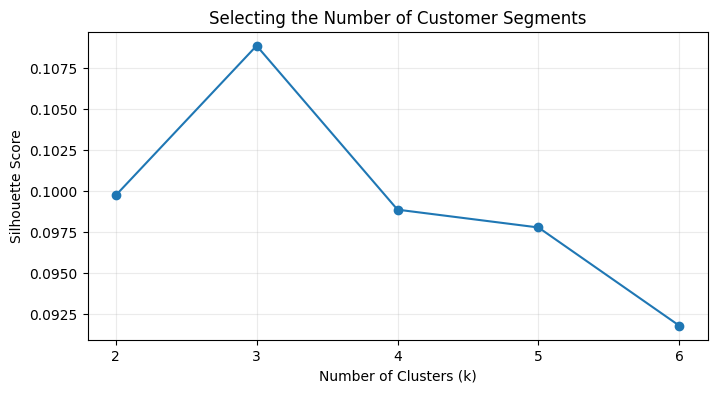

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(
    score_table["k"],
    score_table["silhouette_score"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Selecting the Number of Customer Segments")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.25)
plt.show()


## 8. Build Customer Segments

In [13]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

segments = kmeans.fit_predict(X)

segmented = data.copy()
segmented["Segment"] = segments

print("Segment distribution:")
display(
    segmented["Segment"]
    .value_counts()
    .sort_index()
)


Segment distribution:


Segment
0     716
1    1342
2      77
Name: count, dtype: int64

## 9. Understand the Segments

K-Means only produces cluster IDs. We still need to inspect the original data to understand how the segments differ.


In [14]:
segment_summary = (
    segmented
    .groupby("Segment")[numeric_cols]
    .mean()
    .round(2)
)

display(segment_summary)


,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
Segment,,,,,
0,322.58,25.91,120.24,1.01,1832.07
1,286.10,54.65,119.29,1.01,6813.14
2,279.49,43.86,134.39,3.95,5452.11


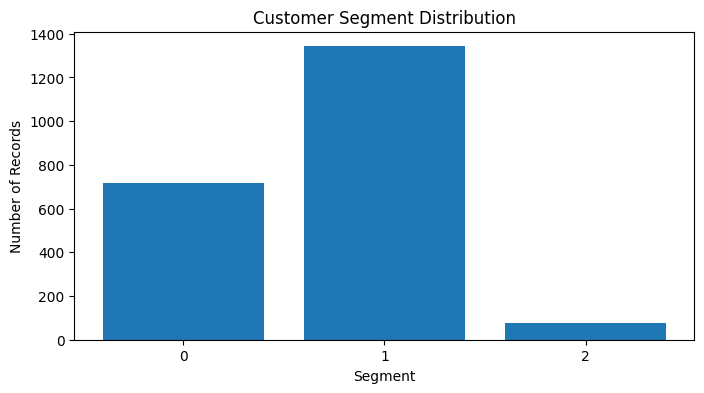

In [15]:
segment_counts = (
    segmented["Segment"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 4))
plt.bar(
    segment_counts.index.astype(str),
    segment_counts.values
)

plt.xlabel("Segment")
plt.ylabel("Number of Records")
plt.title("Customer Segment Distribution")
plt.show()


## 10. Visualize the Segments

PCA is used only to visualize the high-dimensional data in two dimensions. It is not used to create the clusters.


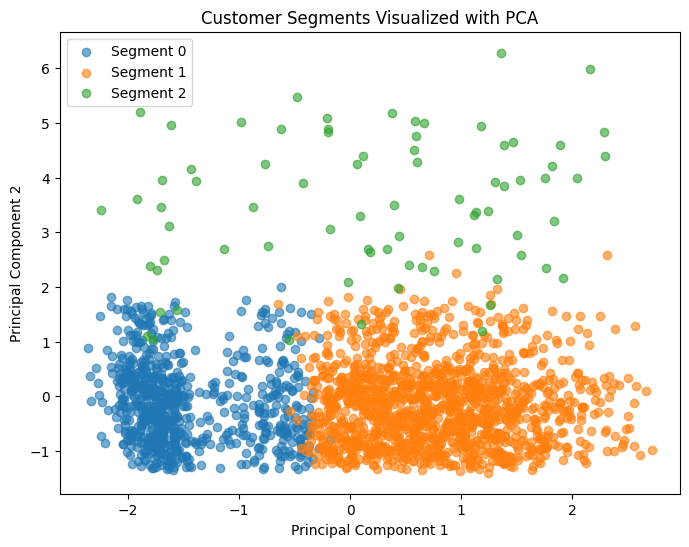

Explained variance: [0.13  0.089]


In [17]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))

for segment_id in sorted(segmented["Segment"].unique()):
    mask = segmented["Segment"].to_numpy() == segment_id

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Segment {segment_id}",
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments Visualized with PCA")
plt.legend()
plt.show()

print(
    "Explained variance:",
    pca.explained_variance_ratio_.round(3)
)


## 11. Build a Classifier for New Customers

The clusters discovered by K-Means can be used as temporary labels.

A Random Forest classifier learns the relationship between the original customer features and the discovered segment IDs. This allows the final application to accept a **new customer profile** without rerunning K-Means every time.

> **Important:** the segment IDs are generated by clustering. They are not real-world ground-truth labels.


In [18]:
X_class = segmented.drop(columns=["Segment"])
y_class = segmented["Segment"]

X_train, X_test, y_train, y_test = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

class_numeric_cols = X_class.select_dtypes(
    include=np.number
).columns.tolist()

class_categorical_cols = X_class.select_dtypes(
    exclude=np.number
).columns.tolist()

classifier_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            class_numeric_cols
        ),
        (
            "categorical",
            OneHotEncoder(**OHE_KWARGS),
            class_categorical_cols
        )
    ],
    remainder="drop"
)

classifier = Pipeline([
    (
        "preprocessor",
        classifier_preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        )
    )
])

classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.84      0.90       143
           1       0.89      1.00      0.94       269
           2       1.00      0.13      0.24        15

    accuracy                           0.92       427
   macro avg       0.96      0.66      0.69       427
weighted avg       0.92      0.92      0.90       427



## 12. Evaluate the Classifier

Confusion Matrix:


,Predicted 0,Predicted 1,Predicted 2
Actual 0,120,23,0
Actual 1,0,269,0
Actual 2,3,10,2


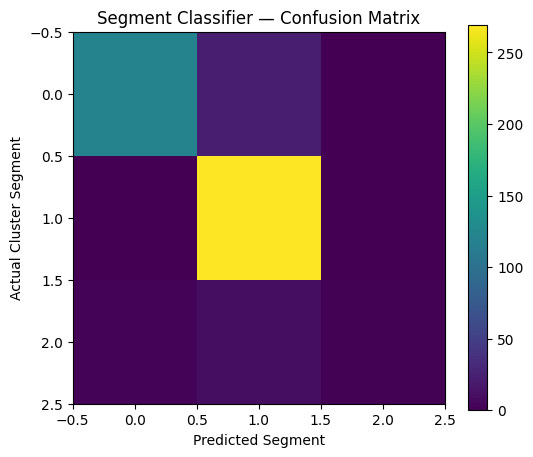

In [19]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
display(
    pd.DataFrame(
        cm,
        index=[f"Actual {i}" for i in sorted(y_class.unique())],
        columns=[f"Predicted {i}" for i in sorted(y_class.unique())]
    )
)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Segment Classifier — Confusion Matrix")
plt.xlabel("Predicted Segment")
plt.ylabel("Actual Cluster Segment")
plt.colorbar()
plt.show()


## 13. Save Everything Needed by the App

The application needs the trained classifier and the segment data. Saving them here means the Streamlit app can load the trained result directly.


In [20]:
artifacts = {
    "classifier": classifier,
    "feature_columns": X_class.columns.tolist(),
    "numeric_columns": class_numeric_cols,
    "categorical_columns": class_categorical_cols,
    "best_k": best_k
}

joblib.dump(
    artifacts,
    "customer_segmentation_artifacts.joblib"
)

segmented.to_csv(
    "customer_segments.csv",
    index=False
)

print("Files created successfully:")
print("1. customer_segmentation_artifacts.joblib")
print("2. customer_segments.csv")


Files created successfully:
1. customer_segmentation_artifacts.joblib
2. customer_segments.csv


# Project Result

The machine learning workflow is now complete.

The final application uses the saved classifier to:

**Customer Profile → Predict Segment → Explain Segment Characteristics**

Run `app.py` with Streamlit after this notebook finishes successfully.
